# DA5400W: Assignment 3 — Customer Lifetime Value Prediction
### PCA + K-Means Clustering + Linear Regression Pipeline

- **Course:** DA5400W — Foundations of Machine Learning  
- **Instructor:** Dr. Arun B Ayyar, IIT Madras  
- **Student Name:** Sohang Chopra 
- **Roll Number:** DA25M622

---

### Background

You are a data scientist at an e-commerce company. The goal is to understand customer behaviour and **predict Customer Lifetime Value (CLV)** — the total revenue a customer is expected to generate.

You are given a dataset of **800 customers** with 8 behavioural features:

| Feature | Description |
|---|---|
| `recency_days` | Days since the customer's last purchase |
| `purchase_frequency` | Number of purchases in the last 12 months |
| `avg_basket_size_gbp` | Average order value (GBP) |
| `num_categories` | Number of distinct product categories purchased |
| `return_rate` | Fraction of orders returned |
| `discount_sensitivity` | Fraction of purchases made with a discount |
| `email_open_rate` | Fraction of marketing emails opened |
| `tenure_months` | Months since the customer registered |

**Target:** `clv_gbp` — estimated Customer Lifetime Value in GBP.

### Marks

| Section | Topic | Marks |
|---|---|---|
| Q1 | PCA — Dimensionality Reduction | 3 |
| Q2 | K-Means Clustering — Customer Segmentation | 3 |
| Q3 | Linear Regression — CLV Prediction | 3 |
| Q4 | Analysis — Interpretation | 1 |
| **Total** | | **10** |

> **Instructions:** Write your code in the empty cells. Do not modify the setup cell. Submit this notebook with all cells executed and outputs visible.


## Setup — Run this cell first, do not modify


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('customer_data.csv')
features = ['recency_days', 'purchase_frequency', 'avg_basket_size_gbp',
            'num_categories', 'return_rate', 'discount_sensitivity',
            'email_open_rate', 'tenure_months']
X_raw = df[features].copy()
y = df['clv_gbp'].copy()
print(f'Dataset: {df.shape[0]} customers, {len(features)} features')
df[features + ['clv_gbp']].describe().round(2)


Dataset: 800 customers, 8 features


,recency_days,purchase_frequency,avg_basket_size_gbp,num_categories,return_rate,discount_sensitivity,email_open_rate,tenure_months,clv_gbp
count,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00
mean,73.83,11.78,61.22,3.39,0.13,0.40,0.23,14.19,364.16
std,72.81,8.70,49.72,2.19,0.08,0.24,0.17,11.59,905.49
min,1.00,1.00,5.00,1.00,0.00,0.00,0.00,1.00,5.00
25%,26.67,2.00,29.55,2.00,0.08,0.21,0.09,5.00,6.24
50%,44.57,11.00,48.76,3.00,0.12,0.35,0.22,12.00,51.31
75%,88.93,18.00,73.65,4.00,0.19,0.60,0.33,21.00,176.82
max,334.78,40.00,279.78,12.00,0.36,1.00,0.76,60.00,5000.00


---
## Q1: PCA — Dimensionality Reduction (3 marks)

**[1 mark]** Standardise the 8 features using `StandardScaler`. Fit a full PCA and plot the **scree plot** (variance per component) and **cumulative explained variance**. State how many components explain at least 80% of the variance.

**[1 mark]** Reduce the data to that number of components (store as `X_pca`). Also create a **2D projection** (PC1 vs PC2) and colour the scatter plot by CLV.

**[1 mark]** Plot the **loadings** of PC1 and PC2. In one sentence each, state what customer characteristic each component captures.




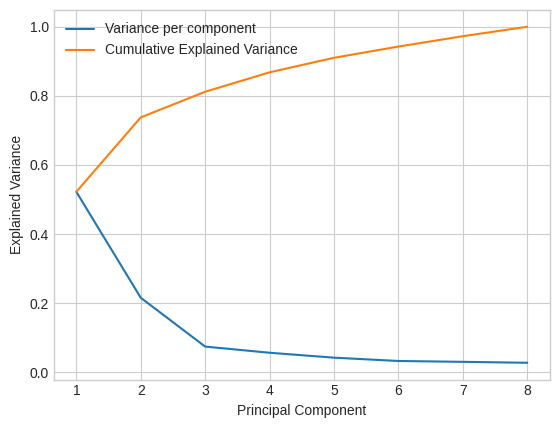

In [26]:
# Q1 Part 1: Standardise features, fit PCA, plot scree + cumulative variance
# Store: X_scaled, n_components
X_scaled = StandardScaler().fit_transform(X_raw)
full_pca = PCA().fit(X_scaled)
variances = full_pca.explained_variance_ratio_
cum_variance = variances.cumsum()
components = np.arange(1, 1 + full_pca.n_components_)
plt.plot(components, variances, label='Variance per component')
plt.plot(components, cum_variance, label='Cumulative Explained Variance')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance')
plt.legend()
plt.show()

From above plot of cumulative variance, first 3 components explain at least 80% of variance.

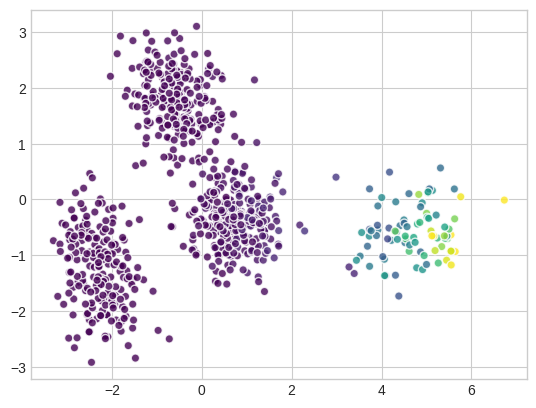

In [16]:
# Q1 Part 2: Reduce to n_components (store as X_pca)
# Also create 2D projection (store as X_pca_2d) and scatter plot coloured by CLV
X_pca = PCA(n_components=3).fit_transform(X_scaled)
pca_2d = PCA(n_components=2).fit(X_scaled)
X_pca_2d = pca_2d.transform(X_scaled)
#kmeans = KMeans(n_clusters=3, random_state=42).fit(X_pca_2d)
#colors = ['red', 'green', 'blue']
plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1], c=y, cmap='viridis', edgecolors='w', alpha=0.8)  #[colors[i] for i in kmeans.labels_])   # TODO: fix plot colors
plt.show()

In [28]:
pca_2d.components_.shape

(2, 8)

In [17]:
y.min(), y.max()

(np.float64(5.0), np.float64(5000.0))

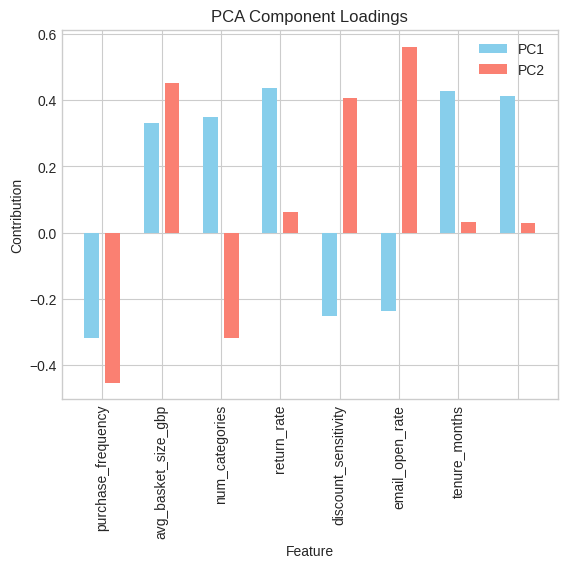

In [18]:
# Q1 Part 3: Plot PC1 and PC2 loadings as bar charts
# Print one-sentence interpretation for each component
x = np.arange(1,9)
width = 0.25
padded_width = 0.35
fig, ax = plt.subplots()
ax.bar(x - padded_width/2, pca_2d.components_[0,:], width, label='PC1', color='skyblue')
ax.bar(x + padded_width/2, pca_2d.components_[1,:], width, label='PC2', color='salmon')
ax.set_xticklabels(features, rotation='vertical')
ax.set_title('PCA Component Loadings')
ax.set_xlabel('Feature')
ax.set_ylabel('Contribution')
ax.legend()
fig.show()

Interpretation of Bar Plot:
* **PC1** is characterized by high return rates, longer tenure, and larger basket sizes, while being negatively associated with high purchase frequency and discount sensitivity.
* **PC2** shows a strong positive correlation with email open rates, discount sensitivity, and basket size, but a negative correlation with purchase frequency and the number of categories shopped.

---
## Q2: K-Means Clustering — Customer Segmentation (3 marks)

**[1 mark]** Run K-Means for k = 2 to 10. Plot the **elbow plot** (inertia vs k) and the **silhouette score** vs k side by side. Based on both plots, choose the best k and justify your choice in a print statement.

**[1 mark]** Fit K-Means with your chosen k on the PCA-reduced data (`X_pca`). Visualise the clusters in the PC1-PC2 space, marking each cluster's centroid with a star.

**[1 mark]** For each cluster, compute the **mean of each original feature**. Print the summary table and write one sentence describing what type of customer each cluster represents.




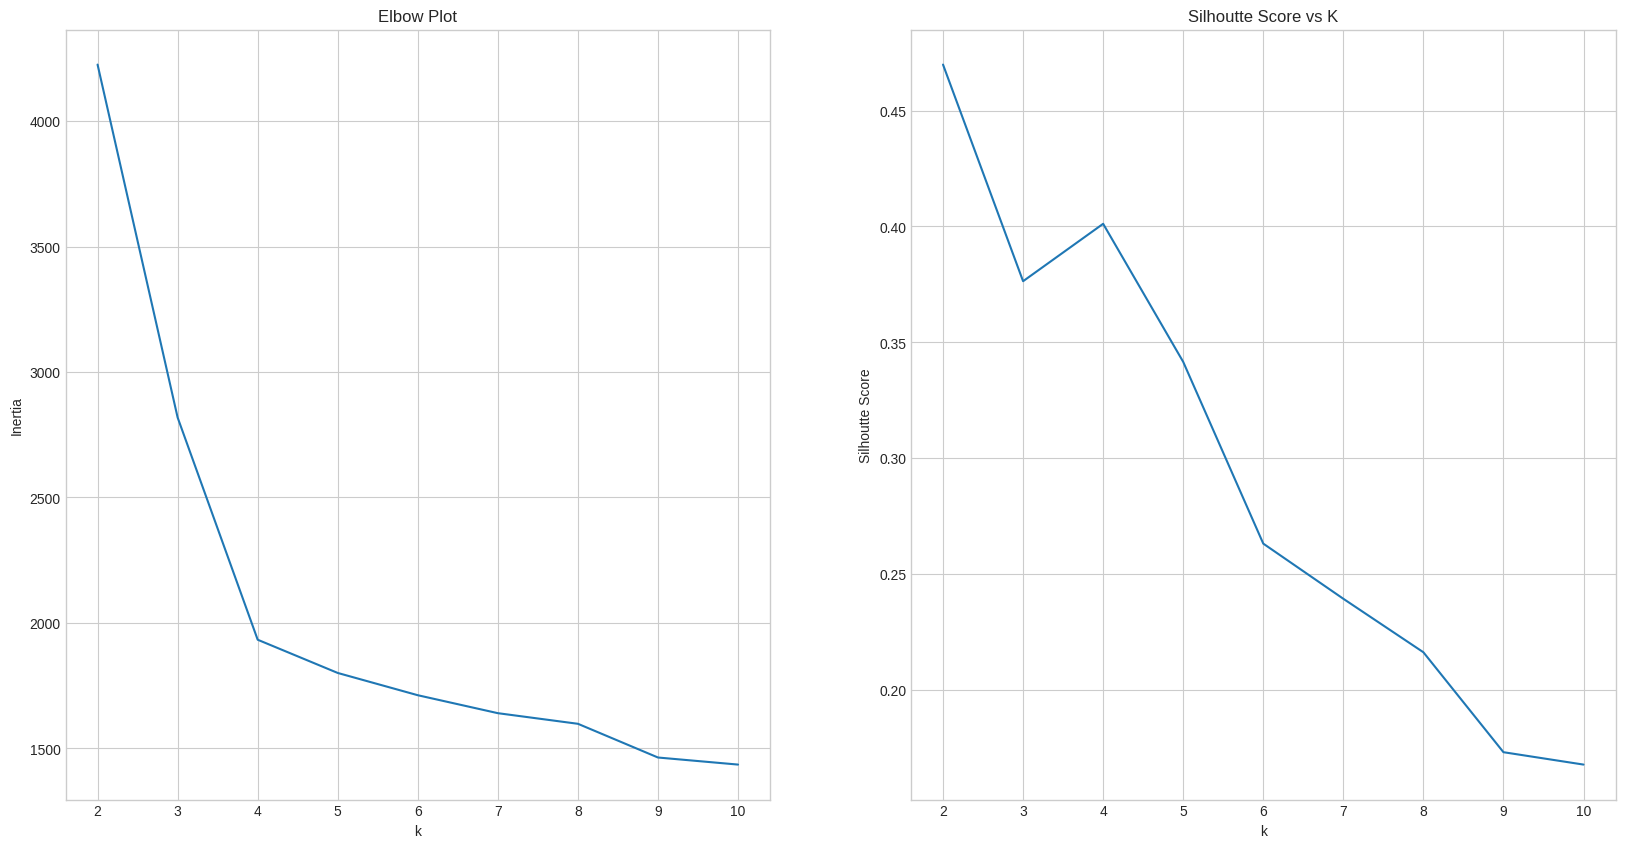

In [30]:
# Q2 Part 1: Elbow plot and silhouette score for k = 2 to 10
# Store: best_k (your chosen number of clusters)
inertias = []
silhouette_scores = []
k_values = np.arange(2, 11)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, cluster_labels))

fig, axes = plt.subplots(1,2, figsize=(20,10))

axes[0].plot(k_values, inertias)
axes[0].set_title('Elbow Plot')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_values, silhouette_scores)
axes[1].set_title('Silhoutte Score vs K')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhoutte Score')

fig.show()

From above plots, best is k=3. We can see "elbow" in Inertia vs k plot at k=3, and silhoutte score plot also peaks at same k=3.

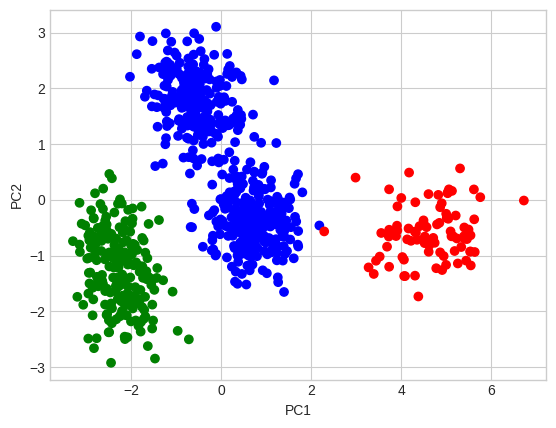

In [20]:
# Q2 Part 2: Fit K-Means with best_k, visualise clusters in PC1-PC2 space
# Store: labels (cluster assignments for all 800 customers)
best_k = 3
labels = KMeans(n_clusters=best_k, random_state=42).fit_predict(X_pca_2d)
colours = ['red', 'green', 'blue']
plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1], c=[colours[i] for i in labels])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [21]:
# Q2 Part 3: Mean feature values per cluster — print summary table
# Write one-sentence description for each cluster
X_raw.groupby(labels).mean().reset_index(names=['cluster_index'])

,cluster_index,recency_days,purchase_frequency,avg_basket_size_gbp,num_categories,return_rate,discount_sensitivity,email_open_rate,tenure_months
0,0,14.729462,25.081395,178.575116,7.895349,0.048709,0.099965,0.546419,35.965116
1,1,183.159006,1.142157,54.012500,1.127451,0.150255,0.386961,0.054951,3.215686
2,2,40.058797,13.788235,44.314745,3.539216,0.141665,0.458212,0.247939,14.909804


Cluster Descriptions:
* **Cluster 0 (Red):** These customers spend the most per visit ($178.58$ average basket), and have the highest long-term tenure and email engagement.
* **Cluster 1 (Green):** These customers who haven't shopped in about six months, have very low purchase frequency, and show minimal engagement with the brand.
* **Cluster 2 (Blue):** These customers shop semi-regularly but are highly sensitive to discounts and typically maintain a smaller basket size.

---
## Q3: Linear Regression — CLV Prediction (3 marks)

**[1 mark]** Split the data 80/20 (train/test, `random_state=42`). Train a `LinearRegression` model on the **raw 8 features** (baseline). Report RMSE and R-squared on the test set.

**[1 mark]** Build a combined feature matrix: **PCA components + one-hot cluster labels**. Train a second `LinearRegression` on this matrix. Report RMSE and R-squared.

**[1 mark]** Plot **predicted vs actual CLV** for both models side by side. Comment on which model performs better.

---
**Hints:**
- `train_test_split(X_raw, y, test_size=0.2, random_state=42)` to split the data
- On the predicted vs actual plot, add a red dashed diagonal (`y = x`) as the perfect prediction line


In [22]:
# Q3 Part 1: Baseline Linear Regression on raw features
# Store: X_train, X_test, y_train, y_test
# Print: RMSE and R2
from sklearn.metrics import root_mean_squared_error
X_train, X_test, y_train, y_test, labels_train, labels_test, X_train_pca2d, X_test_pca2d= train_test_split(
    X_raw, y, labels, X_pca_2d, test_size=0.2, random_state=42
)
linreg = LinearRegression().fit(X_train, y_train)
y_predict = linreg.predict(X_test)
print('RMSE Error:', root_mean_squared_error(y_test, y_predict))
print('R-squared Error:', r2_score(y_test, y_predict))

RMSE Error: 324.3354561652678
R-squared Error: 0.8535958383718592


In [23]:
# Q3 Part 2: Linear Regression on PCA + cluster features
# Print: RMSE and R2
X_train_combined = np.hstack([X_train_pca2d, np.eye(best_k)[labels_train]])  # (train) append one-hot encoded labels
X_test_combined = np.hstack([X_test_pca2d, np.eye(best_k)[labels_test]])     # (test) append one-hot encoded labels
linreg_combined = LinearRegression().fit(X_train_combined, y_train)
y_predict_combined = linreg_combined.predict(X_test_combined)
print('RMSE Error:', root_mean_squared_error(y_test, y_predict_combined))
print('R-squared Error:', r2_score(y_test, y_predict_combined))

RMSE Error: 282.0532223469582
R-squared Error: 0.8892798418957188


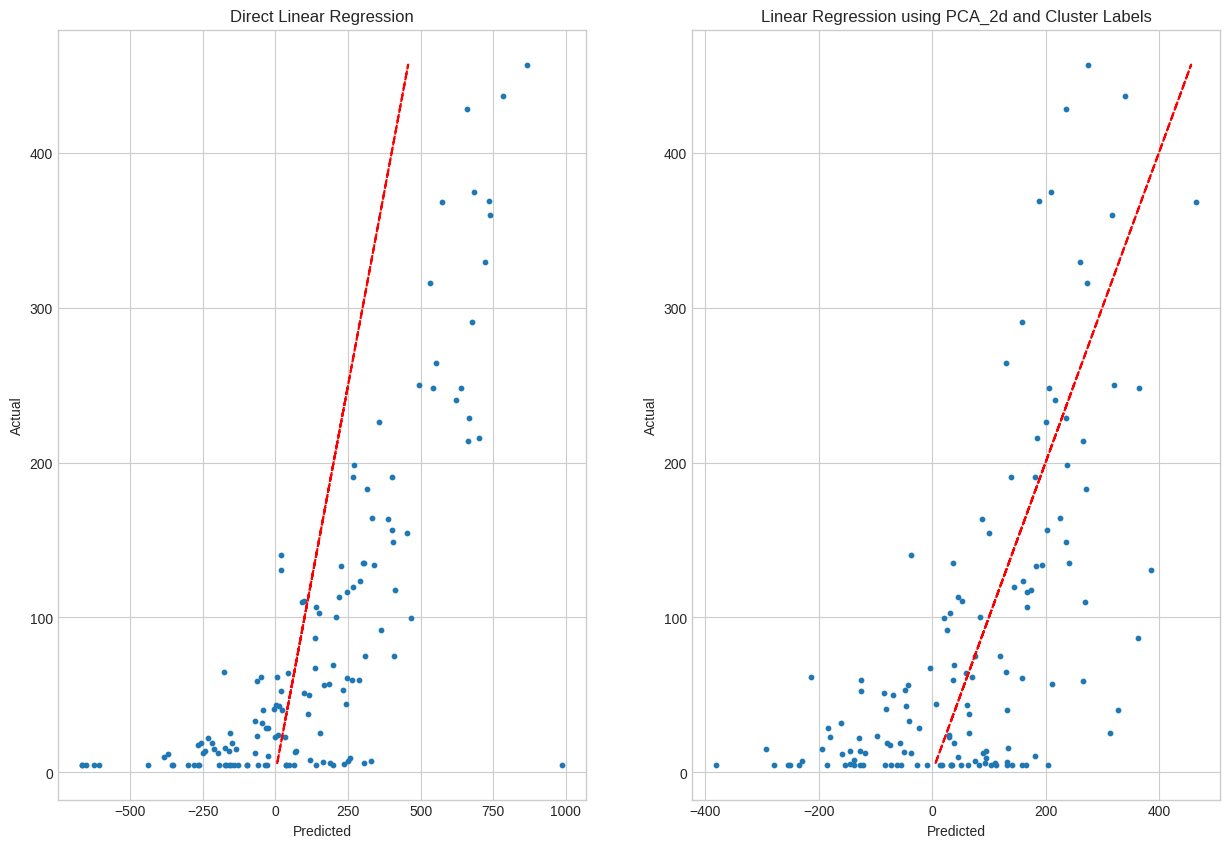

In [24]:
# Q3 Part 3: Predicted vs Actual CLV — both models side by side
mask = y_test <= 500           # remove outliers
y_test_filtered = y_test[mask]

marker_area = 10
fig, axes = plt.subplots(1,2, figsize=(15,10))

axes[0].scatter(y_predict[mask], y_test_filtered, s=marker_area)
axes[0].plot(y_test_filtered, y_test_filtered, 'r--')     # perfect prediction line
axes[0].set_title('Direct Linear Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

axes[1].scatter(y_predict_combined[mask], y_test_filtered, s=marker_area)
axes[1].plot(y_test_filtered, y_test_filtered, 'r--')     # perfect prediction line
axes[1].set_title('Linear Regression using PCA_2d and Cluster Labels')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

fig.show()

Actual vs Predicted plots of both look similar, but PCA + cluster features combined model has significantly lower RMSE error.
Both perform badly (tend to over-predict output, and for low values negative output is predicted but actual outputs are only positive), suggesting that true relationship is non-linear.
PCA + Cluster Features combined is better due to lower RMSE error.

---
## Q4: Analysis (1 mark)

Answer **both** parts below in the markdown cell provided (2–4 sentences each).

**(a)** The elbow plot and silhouette score sometimes suggest different values of k. Explain what each metric measures and how you would decide between them when they disagree.

**(b)** Adding cluster labels as features improved R-squared compared to the baseline. Explain **why** knowing a customer's segment helps a linear regression model predict CLV more accurately.


### Your Answer to Q4

**(a)** Elbow plot measures Inertia, which indicates cohesion (how tightly points are packed within clusters). 
        Silhoutte Score plot incorporates both cohesion (how tightly packed within cluster?) and seperation (inter-cluster distances).
        In case of a tie, k suggested by silhoutte score is generally preferred as it incorporates more information and Elbow method can sometimes be misleading when clusters are not spherical. 

**(b)** R^2 improved (became higher) in case of PCA + cluster features compared to directly using original features.
        Knowing Customer segment (a principal component returned by PCA) helps better linear regression model predict CLV as the prior PCA step captures non-linear relationships, whereas linear regression directly on original features cannot capture non-linearity.
